In [1]:
from NetworkAnalyzer import NetworkAnalyzer

# Test cases

In [4]:
import unittest

In [ ]:
from standardRegArchitercture import SimpleNet
import torch
from torch.utils.data import TensorDataset, DataLoader
import os

In [ ]:
class TestNetworkAnalyzer(unittest.TestCase):
    # Skip This Test Case
    def setUp(self):
        import pandas as pd
        from sklearn.model_selection import train_test_split

        csv_data = pd.read_csv('data/simpleReg.csv')
        a = csv_data['a'].values.reshape(-1, 1)
        b = csv_data['b'].values.reshape(-1, 1)
        y = csv_data['y'].values.reshape(-1, 1)

        a_tensor = torch.tensor(a, dtype=torch.float32)
        b_tensor = torch.tensor(b, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.float32)

        X_tensor = torch.cat((a_tensor, b_tensor), dim=1)
        X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

        batch_size = 64
        self.train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
        self.test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size)
        self.loss_fn = torch.nn.MSELoss()
        self.learning_rate = 0.01
    
    # This is all Black Box ------------------------------------------------------------------------
    def test_check_loss(self):
        # Testing check_loss
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=1, success_loss=1.0)
        analyzer.check_loss(
            train_loader=self.train_loader,
            test_loader=self.test_loader,
            num_epochs=10,
            loss_fn=self.loss_fn,
            learning_rate=self.learning_rate
        )
        # After reset, history should be cleared
        self.assertEqual(len(analyzer.train_loss_history), 0)
        self.assertEqual(len(analyzer.test_loss_history), 0)

    def test_generate_networks(self):
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=1, success_loss=10.0)  # high success_loss to ensure success

        try:
            analyzer.generate_networks(
                train_loader=self.train_loader,
                test_loader=self.test_loader,
                num_epochs=3,
                loss_fn=self.loss_fn,
                learning_rate=self.learning_rate
            )
        except Exception as e:
            self.fail(f"generate_networks() raised an exception: {e}")

        self.assertEqual(analyzer.success_count, 0)
        self.assertEqual(analyzer.attempt, 0)

    def test_generate_networks_multiple(self):
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=5, success_loss=10.0)  # high success_loss to ensure success

        try:
            analyzer.generate_networks(
                train_loader=self.train_loader,
                test_loader=self.test_loader,
                num_epochs=3,
                loss_fn=self.loss_fn,
                learning_rate=self.learning_rate
            )
        except Exception as e:
            self.fail(f"generate_networks() raised an exception: {e}")

        self.assertEqual(analyzer.success_count, 0)
        self.assertEqual(analyzer.attempt, 0)
    
    def test_generate_networks_save_and_count(self):
        # Define the path for the saved networks file
        save_path = "WorkingNetworks/working_networks.pt"
        
        # Delete the file if it exists before the test
        if os.path.exists(save_path):
            os.remove(save_path)

        # Set success_loss high to ensure networks are marked as successful.
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=5, success_loss=100.0)
        
        # Run the generate_networks method to train and save networks.
        analyzer.generate_networks(
            train_loader=self.train_loader,
            test_loader=self.test_loader,
            num_epochs=3,
            loss_fn=self.loss_fn,
            learning_rate=self.learning_rate
        )
        
        # Load the saved working networks from file.
        saved_networks = torch.load("WorkingNetworks/working_networks.pt")
        num_saved_networks = len(saved_networks)
        print("Number of networks saved:", num_saved_networks)
        
        # Assert that 5 networks were saved.
        self.assertEqual(num_saved_networks, 5)
 
 # ----------------------------------------------------------------------------------------------------------------
    ### These are all done using Branch Coverage 
    def test_default_success_criteria(self):
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=5, success_loss=None)
        # Expect the default success loss to be 1.0.
        self.assertEqual(analyzer.__default_success_criteria__(), 1.0)

    def test_default_max_attempts(self):
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=10, success_loss=0.5)
        expected = int(10 * 1.3)
        self.assertEqual(analyzer.__default_max_attempts__(), expected)
    
    def test_compute_loss(self):
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=5, success_loss=0.5)
        model = SimpleNet()
        input_tensor = torch.tensor([[1.0, 2.0]], dtype=torch.float32)
        target_tensor = torch.tensor([[0.0]], dtype=torch.float32)
        loss_fn = torch.nn.MSELoss()
        loss = analyzer.__compute_loss__(model, input_tensor, target_tensor, loss_fn)
        self.assertIsInstance(loss, torch.Tensor)

    def test_is_successful_network_true(self):
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=5, success_loss=0.4)
        # Set up a scenario where the last training loss is below success_loss
        analyzer.train_loss_history = [0.5, 0.3]
        self.assertTrue(analyzer.__is_successful_network__())
    
    def test_is_successful_network_false(self):
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=5, success_loss=0.2)
        analyzer.train_loss_history = [0.5, 0.3]
        self.assertFalse(analyzer.__is_successful_network__())
    
    # These 3 are done using condition Coverage
    # CC
    def test_is_successful_network_both_conditions_true(self):
        # Both conditions are True:
        # - Last training loss (0.3) is <= success_loss (0.4)
        # - The improvement (0.3 - 0.5 = -0.2) is less than convergence_threshold (0.3)
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=5, success_loss=0.4, convergence_threshold=0.3)
        analyzer.train_loss_history = [0.5, 0.3]
        self.assertTrue(analyzer.__is_successful_network__())
    
    # CC
    def test_is_successful_network_condition2_false(self):
        # Condition1 is True, but condition2 is False:
        # - Last training loss (0.5) is <= success_loss (1.0)
        # - However, the difference (0.5 - 0.3 = 0.2) is NOT less than convergence_threshold (set to 0.1)
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=5, success_loss=1.0, convergence_threshold=0.1)
        analyzer.train_loss_history = [0.3, 0.5]
        self.assertFalse(analyzer.__is_successful_network__())

    # CC
    def test_is_successful_network_condition1_false(self):
        # Condition1 is False:
        # - Last training loss (0.45) is greater than success_loss (0.4)
        # (Condition2 is irrelevant once Condition1 fails)
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=5, success_loss=0.4, convergence_threshold=0.3)
        analyzer.train_loss_history = [0.5, 0.45]
        self.assertFalse(analyzer.__is_successful_network__())

    def test_store_successful_network(self):
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=5, success_loss=1.0)
        network = SimpleNet()

        save_path = "WorkingNetworks/working_networks.pt"
        
        # Delete the file if it exists before the test
        if os.path.exists(save_path):
            os.remove(save_path)
        
        initial_success_count = analyzer.success_count  # Expected to be 0 initially
        analyzer.__store_successful_network__(network)
        
        # Check that the success count is incremented by one
        self.assertEqual(analyzer.success_count, initial_success_count + 1)
        # The key should be "network_1" (since success_count was 0 before the call)
        self.assertIn("network_1", analyzer.working_networks)


    def test_stores_broken_network(self):
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=5, success_loss=1.0)
        network = SimpleNet()

        save_path = "BrokenNetworks/broken_networks.pt"
        
        # Delete the file if it exists before the test
        if os.path.exists(save_path):
            os.remove(save_path)
        
        initial_attempt = analyzer.attempt  # Expected to be 0 initially
        # Expected key: "network_{success_count+1}_{attempt}" -> "network_1_0" (since success_count is 0)
        expected_key = f"network_{analyzer.success_count+1}_{initial_attempt}"
        
        analyzer.__store_broken_network__(network)
        
        # Check that the attempt counter is incremented by one
        self.assertEqual(analyzer.attempt, initial_attempt + 1)
        self.assertIn(expected_key, analyzer.broken_networks)

    def test_reset_loss(self):
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=1, success_loss=1.0)
        
        # Pre-populate loss histories with dummy values.
        analyzer.train_loss_history = [0.1, 0.2, 0.3]
        analyzer.test_loss_history = [0.15, 0.25]
        
        # Call the private method to reset the loss histories.
        analyzer.__reset_loss__()
        
        # Verify that both histories have been cleared.
        self.assertEqual(analyzer.train_loss_history, [])
        self.assertEqual(analyzer.test_loss_history, [])

    def test_should_continue_training(self):
        # Create an analyzer with amount_to_produce = 5
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=5, success_loss=1.0)
        # When success_count is less than amount_to_produce, it should continue.
        analyzer.success_count = 3
        self.assertTrue(analyzer.__should_continue_training__())
        # When success_count equals amount_to_produce, it should not continue.
        analyzer.success_count = 5
        self.assertFalse(analyzer.__should_continue_training__())


    def test_max_attempts_reached(self):
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=5, success_loss=1.0, max_attempts=10)
        analyzer.attempt = 9
        self.assertFalse(analyzer.__max_attempts_reached__())
        
        analyzer.attempt = 10
        # Capture print output.
        from unittest.mock import patch
        with patch("builtins.print") as mock_print:
            self.assertTrue(analyzer.__max_attempts_reached__())
            mock_print.assert_called_with("Error: Maximum number of attempts reached without meeting success criteria.")


    def test_initialize_network(self):
        learning_rate = 0.01
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=5, success_loss=1.0)
        network = analyzer.__initialize_network__(learning_rate)
        # Ensure the network is an instance of SimpleNet.
        self.assertIsInstance(network, SimpleNet)
        # Check that the optimizer attribute is set on the network.
        self.assertIsNotNone(getattr(network, "optimizer", None))
        # Verify that the learning rate is correctly set.
        self.assertEqual(network.optimizer.param_groups[0]['lr'], learning_rate)


    def test_display_training_summary_success(self):
        # Test the display when success_count equals amount_to_produce.
        import io
        import sys
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=3, success_loss=1.0)
        analyzer.success_count = 3
        analyzer.attempt = 4

        captured_output = io.StringIO()
        sys.stdout = captured_output

        analyzer.__display_training_summary__()
        
        sys.stdout = sys.__stdout__
        
        expected_output = (f"Successfully trained {analyzer.success_count} networks.\n"
                        f"Attempts: {analyzer.attempt}, Successful Networks: {analyzer.success_count}\n")
        self.assertEqual(captured_output.getvalue(), expected_output)


    def test_display_training_summary_unsuccess(self):
        # Test the display when not all networks were successfully trained.
        import io
        import sys
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=5, success_loss=1.0)
        analyzer.success_count = 2
        analyzer.attempt = 4
        print("Belo this ran")

        captured_output = io.StringIO()
        sys.stdout = captured_output

        analyzer.__display_training_summary__()
        
        sys.stdout = sys.__stdout__
        
        expected_output = (f"{analyzer.success_count} successful networks created out of {analyzer.amount_to_produce}.\n"
                        f"Attempts: {analyzer.attempt}, Successful Networks: {analyzer.success_count}\n")
        self.assertEqual(captured_output.getvalue(), expected_output)


    def test_reset_training_parameters(self):
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=5, success_loss=1.0)
        # Set non-zero values to simulate previous training.
        analyzer.attempt = 7
        analyzer.success_count = 3
        analyzer.__reset_training_parameters__()
        # After resetting, both counters should be zero.
        self.assertEqual(analyzer.attempt, 0)
        self.assertEqual(analyzer.success_count, 0)

    # Verify that __train_one_epoch__ returns the correct average loss.
    def test_train_one_epoch_average_loss(self):
        from unittest.mock import patch
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=1, success_loss=1.0)
        model = SimpleNet()
        optimizer = torch.optim.SGD(model.parameters(), lr=self.learning_rate)
        device = torch.device("cpu")
        epoch = 0
        # Patch __compute_loss__ so that each call returns a tensor with value 1.0.
        with patch.object(analyzer, '__compute_loss__', return_value=torch.tensor(1.0)):
            avg_loss = analyzer.__train_one_epoch__(model, self.train_loader, optimizer, self.loss_fn, device, epoch)
            # Since each batch returns loss 1.0, the average should be 1.0.
            self.assertAlmostEqual(avg_loss, 1.0)

    # Ensure that __show_loss__ is called with the proper arguments.
    def test_train_one_epoch_show_loss_called(self):
        from unittest.mock import patch
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=1, success_loss=1.0)
        model = SimpleNet()
        optimizer = torch.optim.SGD(model.parameters(), lr=self.learning_rate)
        device = torch.device("cpu")
        epoch = 0
        with patch.object(analyzer, '__compute_loss__', return_value=torch.tensor(1.0)):
            with patch.object(analyzer, '__show_loss__') as mock_show:
                avg_loss = analyzer.__train_one_epoch__(model, self.train_loader, optimizer, self.loss_fn, device, epoch)
                # Verify that __show_loss__ was called exactly once with the epoch and the computed average loss.
                mock_show.assert_called_once_with(epoch, avg_loss)

    #Def-use
    # Count the number of optimizer.step() calls equals the number of batches in the train_loader.
    def test_train_one_epoch_optimizer_step_count(self):
        from unittest.mock import patch
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=1, success_loss=1.0)
        model = SimpleNet()
        optimizer = torch.optim.SGD(model.parameters(), lr=self.learning_rate)
        device = torch.device("cpu")
        epoch = 0
        # Count the calls to optimizer.step().
        original_step = optimizer.step
        call_count = [0]  # using a list so it's mutable inside our nested function
        def step_counter(*args, **kwargs):
            call_count[0] += 1
            return original_step(*args, **kwargs)
        optimizer.step = step_counter
        with patch.object(analyzer, '__compute_loss__', return_value=torch.tensor(1.0)):
            analyzer.__train_one_epoch__(model, self.train_loader, optimizer, self.loss_fn, device, epoch)
            # The number of optimizer.step() calls should equal the number of batches in the train_loader.
            self.assertEqual(call_count[0], len(self.train_loader))

    # CC
    def test_train_network_with_test_true(self):
        from unittest.mock import patch

        # Create an analyzer and a dummy model.
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=1, success_loss=1.0)
        model = SimpleNet()
        optimizer = torch.optim.SGD(model.parameters(), lr=self.learning_rate)
        device = torch.device("cpu")
        num_epochs = 3

        # Patch __train_one_epoch__ to return a constant loss each epoch.
        with patch.object(analyzer, '__train_one_epoch__', return_value=0.5) as mock_train_one_epoch:
            # Patch __test_network__ to simply record its call.
            with patch.object(analyzer, '__test_network__') as mock_test_network:
                analyzer.__train_network__(model, self.train_loader, self.test_loader, num_epochs, optimizer, self.loss_fn, device, test=True)
                
                # Check that the training loss history has one entry per epoch.
                self.assertEqual(len(analyzer.train_loss_history), num_epochs)
                # Verify that __train_one_epoch__ is called once per epoch.
                self.assertEqual(mock_train_one_epoch.call_count, num_epochs)
                # Since test is True, __test_network__ should be called each epoch.
                self.assertEqual(mock_test_network.call_count, num_epochs)

    # Still Branch Coverage
    def test_train_network_with_test_false(self):
        from unittest.mock import patch
        # Create an analyzer and a dummy model.
        analyzer = NetworkAnalyzer(SimpleNet, amount_to_produce=1, success_loss=1.0)
        model = SimpleNet()
        optimizer = torch.optim.SGD(model.parameters(), lr=self.learning_rate)
        device = torch.device("cpu")
        num_epochs = 3

        # Patch __train_one_epoch__ to return a constant loss each epoch.
        with patch.object(analyzer, '__train_one_epoch__', return_value=0.7) as mock_train_one_epoch:
            # Patch __test_network__ to track calls.
            with patch.object(analyzer, '__test_network__') as mock_test_network:
                analyzer.__train_network__(model, self.train_loader, self.test_loader, num_epochs, optimizer, self.loss_fn, device, test=False)
                
                # Check that the training loss history has one entry per epoch.
                self.assertEqual(len(analyzer.train_loss_history), num_epochs)
                # Verify that __train_one_epoch__ is called once per epoch.
                self.assertEqual(mock_train_one_epoch.call_count, num_epochs)
                # Since test is False, __test_network__ should never be called.
                mock_test_network.assert_not_called()
                



In [81]:
tests = TestNetworkAnalyzer()

# Black Box Testing
Simply testing the system on some parameters to make sure it meets customer's needs

In [82]:
tests.setUp()

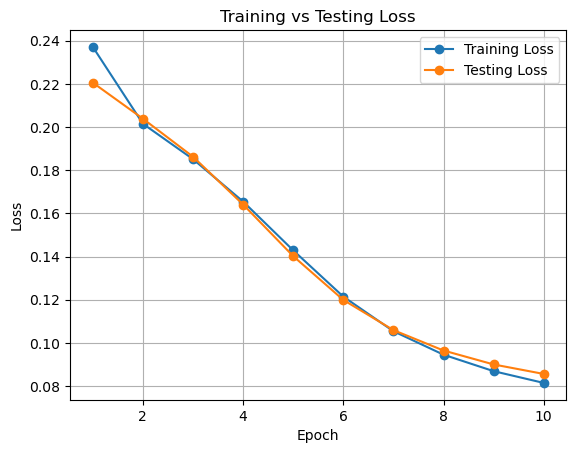

In [83]:
tests.test_check_loss()

In [85]:
tests.test_generate_networks()

In [87]:
tests.test_generate_networks_multiple()

In [42]:
tests.test_generate_networks_save_and_count()

Using mps device!
Training Network 1
Epoch [1], Loss: 0.2164
Epoch [2], Loss: 0.1376
Epoch [3], Loss: 0.1151
Training Network 2
Epoch [1], Loss: 0.2354
Epoch [2], Loss: 0.2165
Epoch [3], Loss: 0.2029
Training Network 3
Epoch [1], Loss: 0.2132
Epoch [2], Loss: 0.1562
Epoch [3], Loss: 0.1439
Training Network 4
Epoch [1], Loss: 0.1943
Epoch [2], Loss: 0.1594
Epoch [3], Loss: 0.1450
Training Network 5
Epoch [1], Loss: 0.2070
Epoch [2], Loss: 0.1940
Epoch [3], Loss: 0.1855
Successfully trained 5 networks.
Attempts: 0, Successful Networks: 5
Number of networks saved: 5


/var/folders/2_/1m71dq416yx4_0rjdssjxckm0000gn/T/ipykernel_85790/2894530882.py:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  saved_networks = torch.load("WorkingNetworks

### White Box Testing

In [77]:
tests.test_default_success_criteria()

In [78]:
tests.test_default_max_attempts()

In [79]:
tests.test_compute_loss()

In [80]:
tests.test_is_successful_network_true()

In [55]:
tests.test_is_successful_network_false()

In [50]:
tests.test_reset_loss()

In [62]:
tests.test_max_attempts_reached()

In [63]:
tests.test_initialize_network()

In [72]:
tests.test_display_training_summary_success()

In [76]:
tests.test_display_training_summary_unsuccess()